In [ ]:
!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.2 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 1. Load the dataset (we don't need the labels for autoencoders)
(x_train, _), (x_test, _) = tf.keras.datasets.fashion_mnist.load_data()

# 2. Normalize and reshape the images to include the channel dimension (28, 28, 1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# 3. Add random Gaussian noise
noise_factor = 0.2
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

# 4. Clip the values to ensure they stay strictly between 0 and 1
x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def build_model(hp):
    inputs = layers.Input(shape=(28, 28, 1))

    # --- ENCODER ---
    # Tune the number of filters in the first convolutional layer
    hp_filters = hp.Int('filters', min_value=16, max_value=64, step=16)

    x = layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(hp_filters // 2, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # --- DECODER ---
    x = layers.Conv2D(hp_filters // 2, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, decoded)

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='binary_crossentropy')

    return model

In [ ]:
# Initialize the tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=5,  # Tests 5 different hyperparameter combinations
    executions_per_trial=1,
    directory='autoencoder_tuning',
    project_name='denoising_fashion_mnist'
)

# Start the search
# We use early stopping to halt trials that aren't improving
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

tuner.search(x_train_noisy, x_train,
             epochs=10,
             validation_split=0.2,
             callbacks=[stop_early])

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best number of filters: {best_hps.get('filters')}")
print(f"Best learning rate: {best_hps.get('learning_rate')}")

Trial 5 Complete [00h 01m 13s]
val_loss: 0.26950910687446594

Best val_loss So Far: 0.2629565894603729
Total elapsed time: 00h 06m 08s
Best number of filters: 64
Best learning rate: 0.001


In [ ]:
# Build the model with the best hyperparameters
best_model = tuner.hypermodel.build(best_hps)

# Train the model
history = best_model.fit(
    x_train_noisy, x_train,
    epochs=15,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.3536 - val_loss: 0.2818
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2781 - val_loss: 0.2759
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.2725 - val_loss: 0.2726
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2688 - val_loss: 0.2705
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2679 - val_loss: 0.2690
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.2665 - val_loss: 0.2677
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2658 - val_loss: 0.2669
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2650 - val_loss: 0.2663
Epoch 9/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2643 - val_loss: 0.2659
Epoch 10/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2637 - val_loss: 0.2655
Epoch 11/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2633 - val_loss: 0.2652
Epoch 12/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/st

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


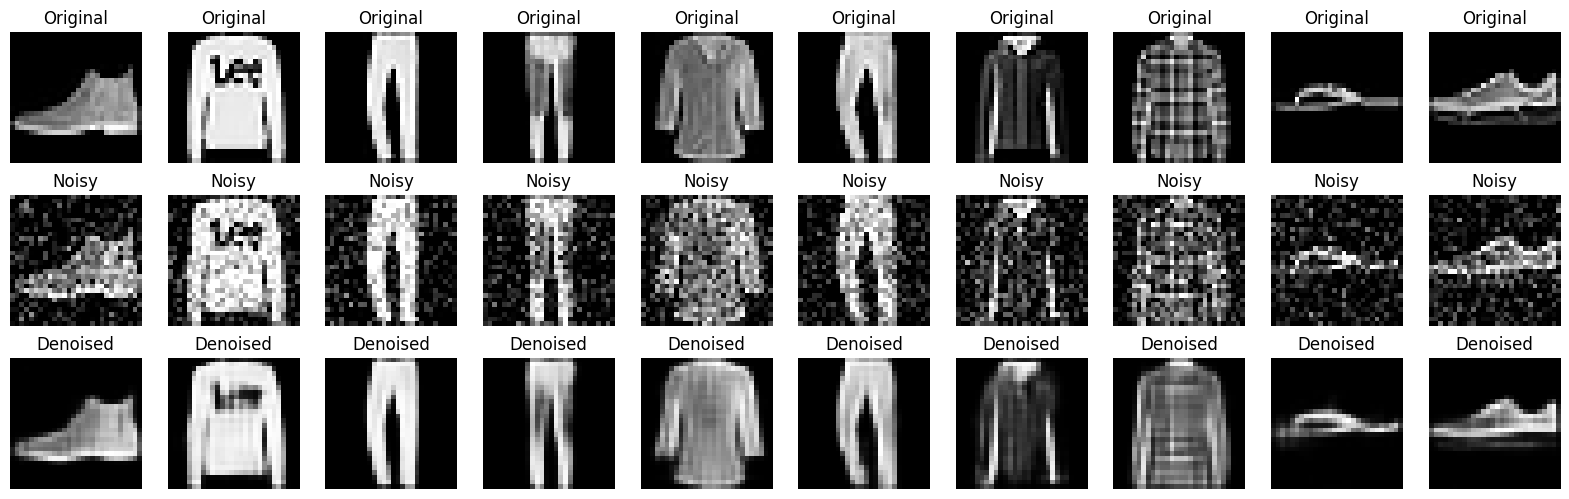

In [ ]:
# Generate denoised images from the noisy test set
decoded_imgs = best_model.predict(x_test_noisy)

# Plotting the Original, Noisy, and Denoised images
n = 10  # Number of images to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display original clean image
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(tf.squeeze(x_test[i]), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Display noisy image
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(tf.squeeze(x_test_noisy[i]), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Display denoised reconstructed image
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(tf.squeeze(decoded_imgs[i]), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.show()

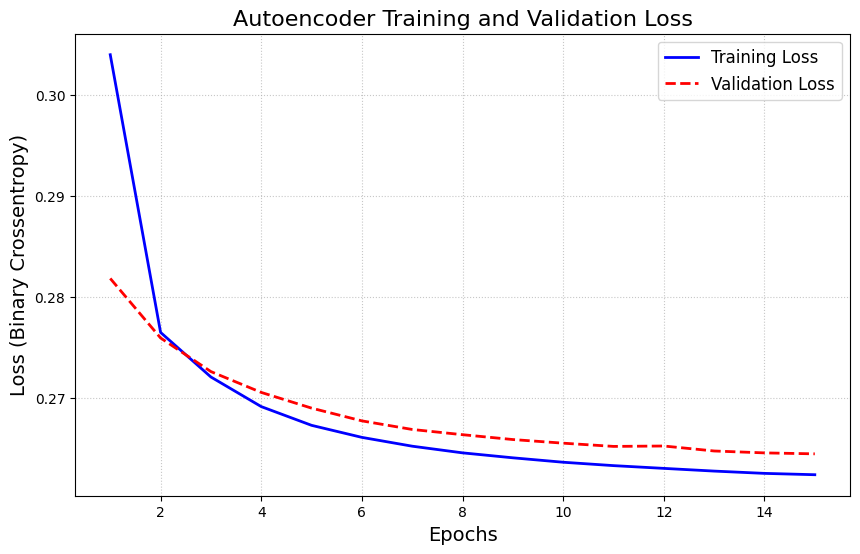

In [ ]:
import matplotlib.pyplot as plt

# The 'history' object is created when you run best_model.fit()
train_loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b-', label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, 'r--', label='Validation Loss', linewidth=2)

plt.title('Autoencoder Training and Validation Loss', fontsize=16)
plt.xlabel('Epochs', fontsize=14)
plt.ylabel('Loss (Binary Crossentropy)', fontsize=14)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

plt.show()

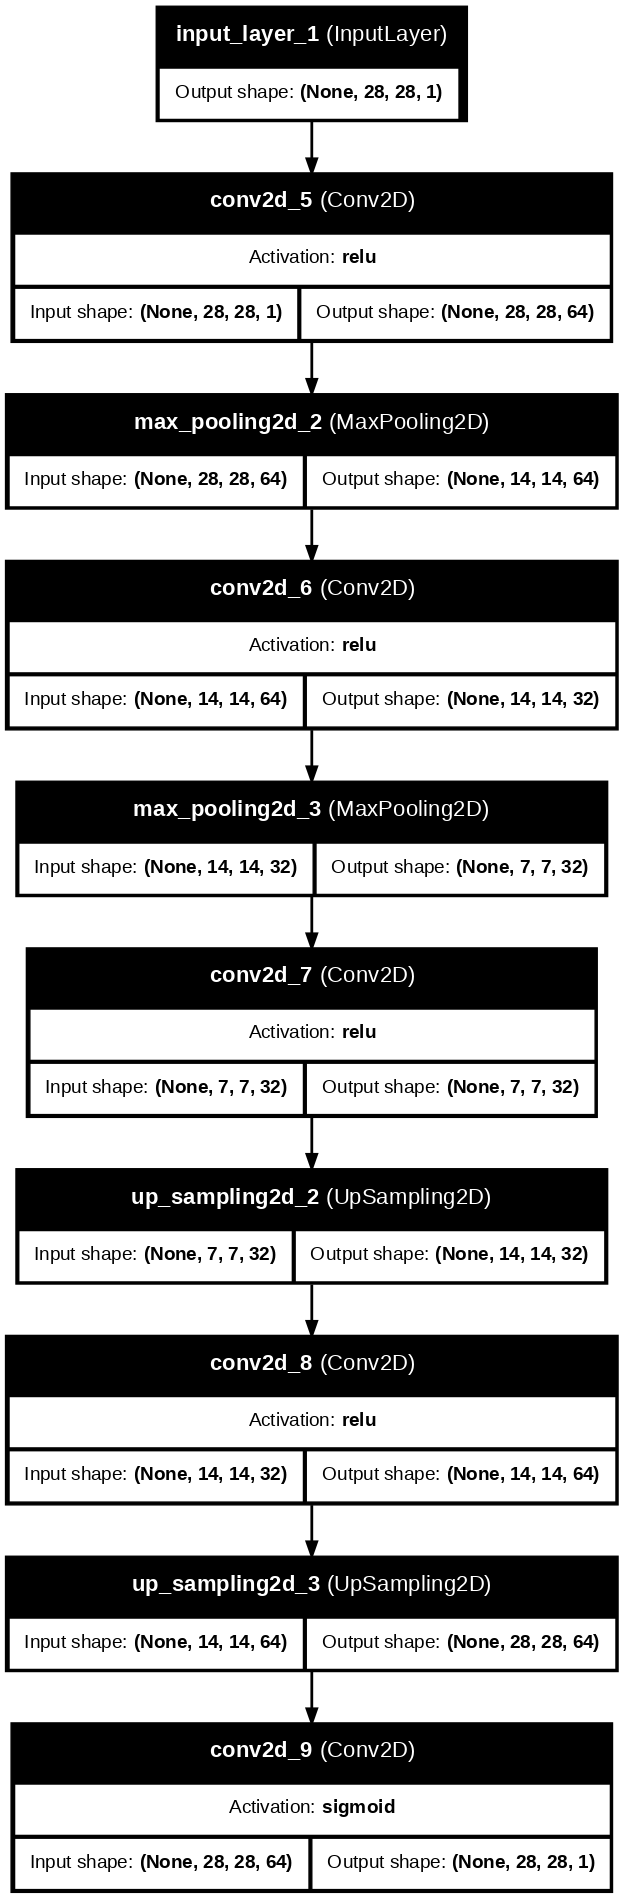

In [ ]:
from tensorflow.keras.utils import plot_model
from IPython.display import Image

# Generate the plot and save it as a PNG file
plot_model(
    best_model,
    to_file='autoencoder_architecture.png',
    show_shapes=True,        # Shows the (Batch_Size, Height, Width, Channels)
    show_layer_names=True,   # Shows the name of the layer (e.g., conv2d_1)
    show_layer_activations=True, # Shows the activation function used (e.g., relu)
    dpi=100                  # Image resolution
)

# Display the image directly in the Colab notebook output
Image('autoencoder_architecture.png')

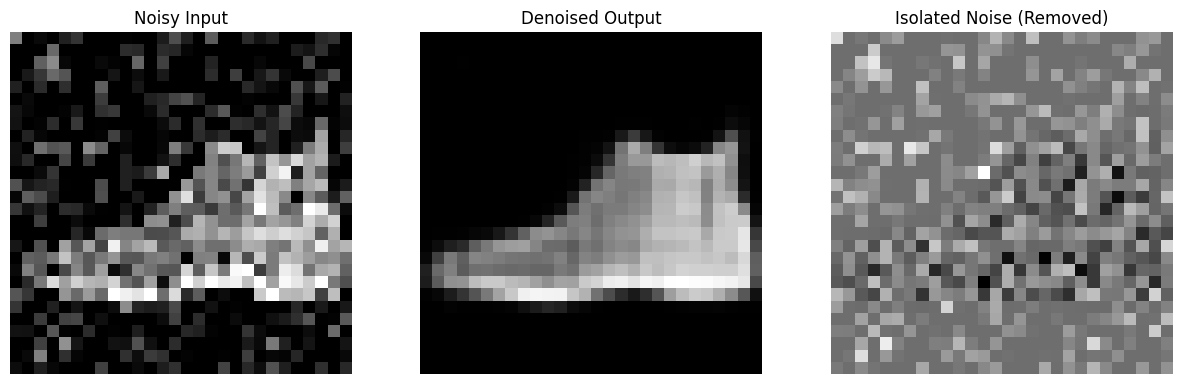

In [ ]:
# Select a single image index to inspect
index = 0

# Calculate the isolated noise (Noisy Image - Denoised Image)
isolated_noise = x_test_noisy[index] - decoded_imgs[index]

plt.figure(figsize=(15, 5))

# Noisy Input
ax = plt.subplot(1, 3, 1)
plt.imshow(tf.squeeze(x_test_noisy[index]), cmap='gray')
plt.title("Noisy Input")
plt.axis("off")

# Denoised Output
ax = plt.subplot(1, 3, 2)
plt.imshow(tf.squeeze(decoded_imgs[index]), cmap='gray')
plt.title("Denoised Output")
plt.axis("off")

# The noise the model removed
ax = plt.subplot(1, 3, 3)
plt.imshow(tf.squeeze(isolated_noise), cmap='gray')
plt.title("Isolated Noise (Removed)")
plt.axis("off")

plt.show()